### Notebook to analyze how increasing the number of binary thresholds tested increases the time spent running and accuracy returned
This tests 1 threshold, 2 thresholds, 3 thresholds, 4 thresholds, 5 thresholds, 10 thresholds, and 20 thresholds and plots their timing and accuracy.

This is to test out the theory that more thresholds returns enough accuracy increases that the time increase is worth it.

What that break-even point on timing and accuracy however is not obvious, thus this notebook.

In [2]:
## Import Cell
import json
import statistics as stats
import pandas as pd
import puck.experiments.best_timing.iterative_thresholding_timing as itt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

output_file_dict is a dictionary that returns the paths where the outputs of running itt.main() are saved


adjustment_on adds in the prefix determined by adjustment, which is default, "../", and is off.


cli_printout prints out some metadata to the command line interface, because you're using the notebook to access this, I recommend turnning it off.


Typical dictionary keys are "accuracy_dict" and "timing_dict" where
-  accuracy_dict's value is the path to the .json file with the accuracy results stored, typically under the "experimental_results" folder
-  timing_dict's value is the path to the .json file with the timing results stored, typically under the "timing_results" folder


A progress bar will show up beneath the cell that is running this, you can use this to approximate how long the cell will take to run. The more hyperparameters tested, the more time it will likely take.

In [3]:
output_file_dict = itt.main(adjustment_on= True)

100%|██████████| 96/96 [00:55<00:00,  1.72it/s]

This is a timing test run on ../data/images_miniset, for the iterative paper programs thresholding method.
It saves ../output/experimental_results/iterative_dict.json and ../output/timing_results/timing_iterative_dict.json.


In [4]:
## Inspect the output_file_dict, if something is very off, adjust how you're running the cell above.
output_file_dict

{'accuracy_dict': '../output/experimental_results/iterative_dict.json',
 'timing_dict': '../output/timing_results/timing_iterative_dict.json'}

Inspect the timing_data, it should return a dictionary with integers as keys and large numbers in a long array as their values.

Those large numbers in the array are the nanoseconds it takes to run at that threshold count (which are indicated by the key integers)

The key integers go up in steps of 1, but actually correspond to the indicies of the 1,2,3,4,5,10,20 values.

In [5]:
with open(output_file_dict.get("timing_dict") , "r") as json_file:
    timing_data = dict(json.loads(json_file.read()))
timing_data

{'0': [19163084,
  15981459,
  14777500,
  16777625,
  19358250,
  20009166,
  18897208,
  15090125,
  18392709,
  18257416,
  19439708,
  16166375,
  9174208,
  9866333,
  9117666,
  9553500,
  9841416,
  9628959,
  9381208,
  10970333,
  10380334,
  10525625,
  9304959,
  9901667,
  17725958,
  17672291,
  14929167,
  18087041,
  13206375,
  13788583,
  12834458,
  12210083,
  11630500,
  13722125,
  11756125,
  11973875,
  15921250,
  20414500,
  14308208,
  17502250,
  13972000,
  14756208,
  14605375,
  14748000,
  12108167,
  16380250,
  15891042,
  17449500,
  11864791,
  12589500,
  13649542,
  13161333,
  14122916,
  14892416,
  14774583,
  13160583,
  14542583,
  15491250,
  13337125,
  14246125,
  10630125,
  8604875,
  10294375,
  8589709,
  14737958,
  9668584,
  9729084,
  10138541,
  9336834,
  11718375,
  11198625,
  10806625,
  40153583,
  30052917,
  25333125,
  25970375,
  14653542,
  17115750,
  22002834,
  16868167,
  12131084,
  11205083,
  10665208,
  12316500,
 

Reassigning the dictionary arrays to arrays with names associated with their threshold value rather than the index value they're associated with in the dictionary. 

This is purely for my own brain's convenience, you could keep them all as timing_data["#"] and be fine.

In [6]:
times_1 = timing_data["0"]
times_2 = timing_data["1"]
times_3 = timing_data["2"]
times_4 = timing_data["3"]
times_5 = timing_data["4"]
times_10 = timing_data["5"]
times_20 = timing_data["6"]

Divide by 1,000,000 to reduce the nanoseconds to milliseconds, a slightly more readable number. 

Test that the results seem reasonable (ie you aren't making HUGE math mistakes before you move onto applying this to all the timing data)

In [7]:
times_1_ms = [ t / 1_000_000 for t in times_1]
times_1_ms

[19.163084,
 15.981459,
 14.7775,
 16.777625,
 19.35825,
 20.009166,
 18.897208,
 15.090125,
 18.392709,
 18.257416,
 19.439708,
 16.166375,
 9.174208,
 9.866333,
 9.117666,
 9.5535,
 9.841416,
 9.628959,
 9.381208,
 10.970333,
 10.380334,
 10.525625,
 9.304959,
 9.901667,
 17.725958,
 17.672291,
 14.929167,
 18.087041,
 13.206375,
 13.788583,
 12.834458,
 12.210083,
 11.6305,
 13.722125,
 11.756125,
 11.973875,
 15.92125,
 20.4145,
 14.308208,
 17.50225,
 13.972,
 14.756208,
 14.605375,
 14.748,
 12.108167,
 16.38025,
 15.891042,
 17.4495,
 11.864791,
 12.5895,
 13.649542,
 13.161333,
 14.122916,
 14.892416,
 14.774583,
 13.160583,
 14.542583,
 15.49125,
 13.337125,
 14.246125,
 10.630125,
 8.604875,
 10.294375,
 8.589709,
 14.737958,
 9.668584,
 9.729084,
 10.138541,
 9.336834,
 11.718375,
 11.198625,
 10.806625,
 40.153583,
 30.052917,
 25.333125,
 25.970375,
 14.653542,
 17.11575,
 22.002834,
 16.868167,
 12.131084,
 11.205083,
 10.665208,
 12.3165,
 14.2285,
 15.965583,
 15.572833

Repeat the process above, moving the nanoseconds into the milliseconds, then divide that again by the number of thresholds that were run.

This results in two useful arrays, 
1) An array that contains the overall time it took to run the whole dot recognition process in milliseconds (times_#_ms) for that image
2) An array that contains the individual time it took to run each threshold in miliseconds (times_per_#_ms) for that image


In [8]:
times_2_ms = [ t / 1_000_000 for t in times_2] ## this is the time it takes to run 2 of these
times_per_2_ms  = [ t / 2 for t in times_2_ms] ## this is the time it takes to run one run
times_per_2_ms

[11.9835835,
 12.117,
 11.4272915,
 14.3127085,
 16.509833,
 16.6453335,
 15.345896,
 11.777771,
 14.79975,
 13.358646,
 14.1676665,
 12.476146,
 7.1243125,
 7.266875,
 6.8751875,
 6.998083,
 9.1938335,
 7.4124375,
 7.7275835,
 9.257604,
 8.235292,
 10.246479,
 7.0721875,
 8.9308955,
 12.1013125,
 12.2549375,
 11.0115835,
 11.7580205,
 9.547292,
 9.8587915,
 8.419979,
 8.132833,
 8.3831665,
 10.3805415,
 9.1702915,
 8.1851875,
 10.816625,
 14.874021,
 10.702542,
 13.1991665,
 12.797125,
 10.739021,
 10.9369375,
 10.7088545,
 9.6546875,
 11.4542085,
 10.727833,
 12.5573335,
 8.9603545,
 9.5679585,
 10.5699375,
 10.6047085,
 11.7949375,
 13.2109585,
 13.112979,
 11.794,
 11.3553545,
 13.9512085,
 10.95825,
 12.058625,
 8.1858335,
 6.7564375,
 7.4966665,
 6.5929375,
 15.3184375,
 7.243875,
 8.2293335,
 7.8406455,
 6.892125,
 8.4617085,
 8.974417,
 9.375,
 28.053208,
 29.175875,
 23.990833,
 23.771146,
 10.5165625,
 12.1120415,
 16.463625,
 12.0042085,
 8.697375,
 7.9723335,
 7.611625,
 9.

Repeat that process for 3, 4, 5, 10, and 20 thresholds, generating the total and individual thresholding times in milliseconds

In [9]:
times_3_ms = [ t / 1_000_000 for t in times_3] ## this is the time it takes to run 3 of these
times_per_3_ms  = [ t / 3 for t in times_3_ms] ## this is the time it takes to run one run
times_4_ms = [ t / 1_000_000 for t in times_4] ## this is the time it takes to run 4 of these
times_per_4_ms  = [ t / 4 for t in times_4_ms] ## this is the time it takes to run one run
times_5_ms = [ t / 1_000_000 for t in times_5] ## this is the time it takes to run 5 of these
times_per_5_ms  = [ t / 5 for t in times_5_ms] ## this is the time it takes to run one run
times_10_ms = [ t / 1_000_000 for t in times_10] ## this is the time it takes to run 3 of these
times_per_10_ms  = [ t / 10 for t in times_10_ms] ## this is the time it takes to run one run
times_20_ms = [ t / 1_000_000 for t in times_20] ## this is the time it takes to run 4 of these
times_per_20_ms  = [ t / 20 for t in times_20_ms] ## this is the time it takes to run one run


Condense this information even further, by finding the average time per threshold across all the options into a dicitonary called `avg_per_ms`

In [10]:
avg_per_ms = {"1" : stats.mean(times_1_ms),
              "2" : stats.mean(times_per_2_ms),
              "3" : stats.mean(times_per_3_ms),
              "4" : stats.mean(times_per_4_ms),
              "5" : stats.mean(times_per_5_ms),
              "10" : stats.mean(times_per_10_ms),
              "20" : stats.mean(times_per_20_ms),}
avg_per_ms

{'1': 14.7152156875,
 '2': 11.454156703125,
 '3': 11.523313211805556,
 '4': 12.672900286458333,
 '5': 11.789157647916667,
 '10': 14.988304944791667,
 '20': 10.541178513541666}

Similarly condense the information by finding the average time per total run across all options into a diciontary called `avg_ms`

In [11]:
avg_ms = {"avg_1" : stats.mean(times_1_ms),
              "avg_2" : stats.mean(times_2_ms),
              "avg_3" : stats.mean(times_3_ms),
              "avg_4" : stats.mean(times_4_ms),
              "avg_5" : stats.mean(times_5_ms),
              "avg_10" : stats.mean(times_10_ms),
              "avg_20" : stats.mean(times_20_ms),}
avg_ms

{'avg_1': 14.7152156875,
 'avg_2': 22.90831340625,
 'avg_3': 34.56993963541667,
 'avg_4': 50.69160114583333,
 'avg_5': 58.94578823958334,
 'avg_10': 149.88304944791668,
 'avg_20': 210.82357027083333}

Inspect the iterative_data, it should return a dictionary with filenames as keys and an array of values (as their value) that tell you about the accuracy.

In the value arrays there will be boolean values, these indicate if the image sucessfully found 4 dots close enough to the ground truth, and if those 4 dots were the only dots found. It also contains a count of the dots found, hereafter referred to as the "blob count".

In [12]:
with open(output_file_dict.get("accuracy_dict") , "r") as json_file:
    iterative_data = dict(json.loads(json_file.read()))
iterative_data 

{'../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.1': [1,
  4,
  True,
  True,
  19163084,
  [0.0, 0.0, 1.0, 1.0]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.2': [2,
  4,
  True,
  True,
  23967167,
  [0.0, 0.0, 1.0, 1.0]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.3': [3,
  4,
  True,
  True,
  35002250,
  [0.0, 1.0, 1.0, 1.0]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.4': [4,
  5,
  True,
  False,
  48556333,
  [0.0, 1.0, 1.0, 1.0, 885.641010793877]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.5': [5,
  5,
  True,
  False,
  61164916,
  [0.0, 1.0, 1.0, 1.0, 885.641010793877]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.10': [10,
  5,
  True,
  False,
  156503417,
  [0.0, 1.0, 1.0, 1.0, 885.641010793877]],
 '../data/images_miniset/custom/davids/high/A/custom_davids_high_A_0.jpg.20': [20,
  6,
  True,
  False,
 

These are used to count how many "correct" images were found per threshold set, using a for loop to construct a dictionary of counts of how many they found correctly.

In [13]:
list_responses = iterative_data.values()
correct_count_dict = {"1" : 0,
              "2" : 0,
              "3" : 0,
              "4" : 0,
              "5" : 0,
              "10" : 0,
              "20" : 0}
for r in list_responses:
    [thresh_count, blob_count, closeEnough, correct, time, distances] = r ## this is the threshold count
    count = correct_count_dict.get(str(thresh_count))
    if correct:
        count += 1
    correct_count_dict.update({str(thresh_count): count})
correct_count_dict  

{'1': 78, '2': 85, '3': 84, '4': 82, '5': 83, '10': 77, '20': 74}

Then that dictionary is transformed into a dictionary of the ratio of correct images : overall images in the dataset checked. This dicitonary is called `correct_ratio_dict`

In [14]:
correct_ratio_dict= {}
for key in correct_count_dict.keys():
    count = correct_count_dict.get(key)
    correct_ratio_dict.update({key: count/96})
correct_ratio_dict

{'1': 0.8125,
 '2': 0.8854166666666666,
 '3': 0.875,
 '4': 0.8541666666666666,
 '5': 0.8645833333333334,
 '10': 0.8020833333333334,
 '20': 0.7708333333333334}

All of these dictionaries are then turned into a dataframe where the columns are the: threshcount, average total to run the thresholds, average time per threshold run, and their accuracy.

There are entries corresponding to each tested threshold set, 1, 2, 3, 4, 5, 10, and 20

In [15]:
df = pd.DataFrame(data={"thresh_count":[1,2,3,4,5,10,20]})
df['averageTimeTotal'] = df.apply(lambda row: avg_ms.get(f"avg_{str(row.thresh_count)}"), axis=1)
df['averageTimePer2'] = df.apply(lambda row: avg_per_ms.get(str(row.thresh_count)), axis=1)
df['averageTimePer'] = df.apply(lambda row: avg_per_ms.get(str(row.thresh_count)), axis=1)
df['accuracy'] = df.apply(lambda row: correct_ratio_dict.get(f"{str(row.thresh_count)}"), axis=1)

df.drop("averageTimePer2", axis = 1)


,thresh_count,averageTimeTotal,averageTimePer,accuracy
0,1,14.715216,14.715216,0.812500
1,2,22.908313,11.454157,0.885417
2,3,34.569940,11.523313,0.875000
3,4,50.691601,12.672900,0.854167
4,5,58.945788,11.789158,0.864583
5,10,149.883049,14.988305,0.802083
6,20,210.823570,10.541179,0.770833


Then we plot the threshold count against the time total it takes to run, so we can see how much the time increases per threshold add, approximently

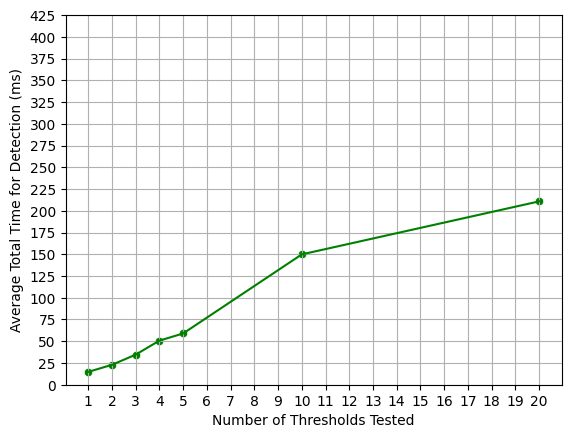

In [16]:
sns.lineplot(data=df, x="thresh_count", y="averageTimeTotal",color = "green", )
sns.scatterplot(data=df, x="thresh_count", y="averageTimeTotal",color = "green")
plt.xlabel("Number of Thresholds Tested")
plt.ylabel("Average Total Time for Detection (ms)")
plt.yticks(np.arange(0, 450, step=25))
plt.xticks(np.arange(1, 21, step=1))
plt.grid()

Similarly we plot the threshold count against the overall accuracy, so we can see how much accuracy increases relative to a threshold increase.

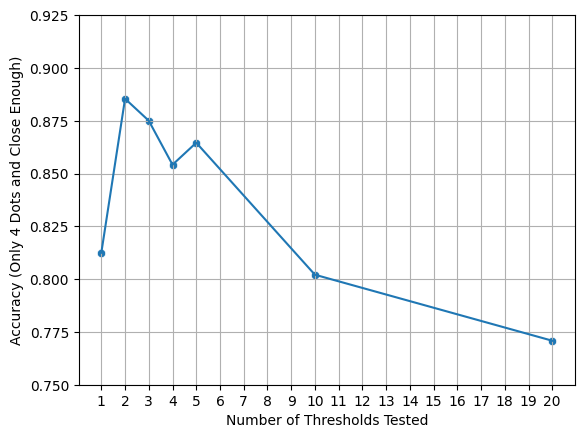

In [17]:
sns.lineplot(data=df, x="thresh_count", y="accuracy")
sns.scatterplot(data=df, x="thresh_count", y="accuracy")
plt.ylim([.75, .9])
plt.xlabel("Number of Thresholds Tested")
plt.ylabel("Accuracy (Only 4 Dots and Close Enough)")
plt.yticks(np.arange(.75,.95,.025))
plt.xticks(np.arange(1,21,1))
plt.grid()

Combining these ideas, we can compare the average time per run (which increases near proportionally) to the accuracy. The further in the x axis, the worse the timing is.

We'd expect to see an upward curve that shows an increase in accruacy for the increased checks, however it starts to drop of as soon as the iterations are greater than 2.

This is likely due to the greedy iteration algorithm, causing the accuracy to go down because it is getting more than 4 dots with the increased iterations.

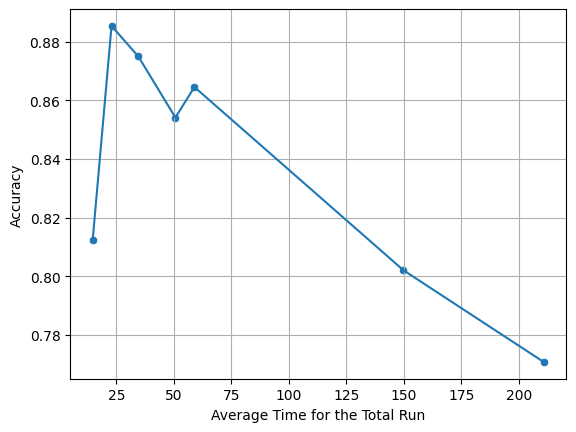

In [25]:
sns.lineplot(data=df, x="averageTimeTotal", y="accuracy")
sns.scatterplot(data=df, x="averageTimeTotal", y="accuracy")
plt.xlabel("Average Time for the Total Run")
plt.ylabel("Accuracy")
# plt.xticks(np.arange(1,21,1))
plt.grid()

And just for fun, we can see on average how long each run takes across different overall iteration counts. 

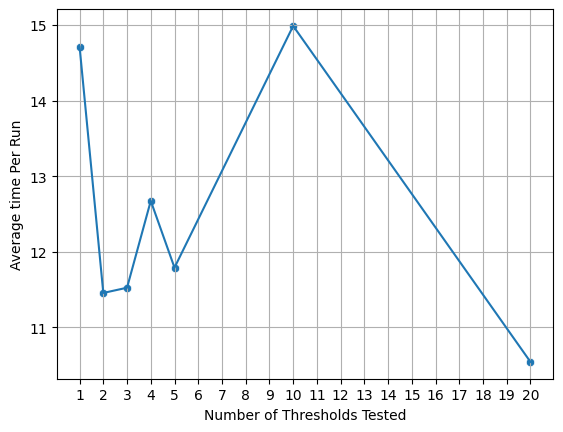

In [29]:
sns.lineplot(data=df, x="thresh_count", y="averageTimePer")
sns.scatterplot(data=df, x="thresh_count", y="averageTimePer")
# plt.ylim([.75, .9])
plt.xlabel("Number of Thresholds Tested")
plt.ylabel("Average time Per Run")
# plt.yticks(np.arange(.75,.95,.025))
plt.xticks(np.arange(1,21,1))
plt.grid()

A count of "close enough" accuracy was made, but since literally every run was close enough, this data tells us nothing very useful.

In [19]:
list_responses = iterative_data.values()
close_count_dict = {"1" : 0,
              "2" : 0,
              "3" : 0,
              "4" : 0,
              "5" : 0,
              "10" : 0,
              "20" : 0}
for r in list_responses:
    [thresh_count, blob_count, closeEnough, correct, time, distances] = r ## this is the threshold count
    count = close_count_dict.get(str(thresh_count))
    if closeEnough:
        count += 1
    close_count_dict.update({str(thresh_count): count})
close_count_dict  

{'1': 96, '2': 96, '3': 96, '4': 96, '5': 96, '10': 96, '20': 96}